
Model      | Test Acc  
-------------------------
SLP        | 0.6631
MLP        | 0.8354
CNN        | 0.8990


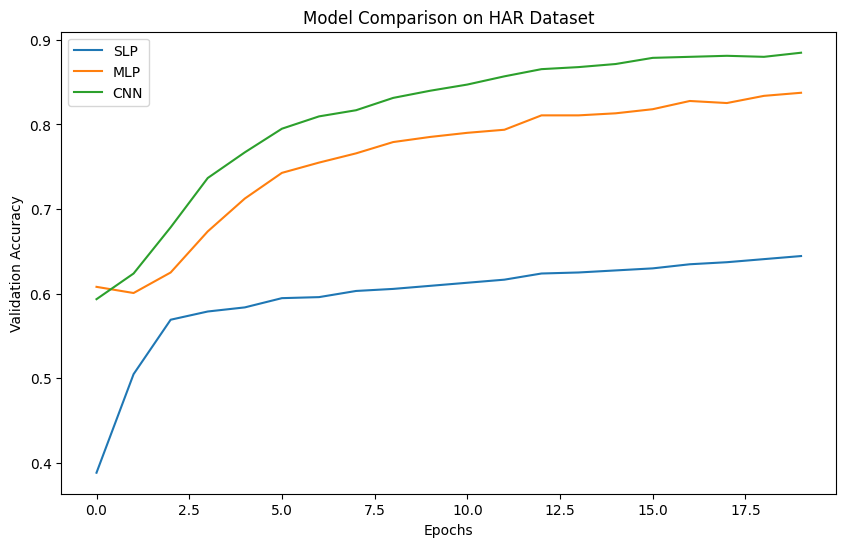

In [40]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)


df = pd.read_csv('HAR_35colums_22L-7683 & 22L-6246.csv')


X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

le = LabelEncoder()
y = le.fit_transform(y_raw)
NUM_CLASSES = len(np.unique(y))
y = keras.utils.to_categorical(y, NUM_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

input_dim = X_train.shape[1]


def build_slp():
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name="SLP")
    return model

def build_mlp():
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name="MLP")
    return model

def build_cnn_1d():
    model = keras.Sequential([
        layers.Input(shape=(input_dim, 1)),
        layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
        layers.Flatten(),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name="CNN_1D")
    return model


models_to_run = [
    ("SLP", build_slp(), X_train, X_test),
    ("MLP", build_mlp(), X_train, X_test),
    ("CNN", build_cnn_1d(), X_train_cnn, X_test_cnn)
]

history_dict = {}
results = []

print(f"\n{'Model':<10} | {'Test Acc':<10}")
print("-" * 25)

for name, model, x_tr, x_te in models_to_run:
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

    history = model.fit(x_tr, y_train, epochs=20, batch_size=32, verbose=0, validation_split=0.1)
    history_dict[name] = history

    loss, acc = model.evaluate(x_te, y_test, verbose=0)
    results.append({'Model': name, 'Accuracy': acc})
    print(f"{name:<10} | {acc:.4f}")

plt.figure(figsize=(10, 6))
for name in history_dict:
    plt.plot(history_dict[name].history['val_accuracy'], label=name)
plt.title('Model Comparison on HAR Dataset')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()


--- PART A: K-Fold Cross-Validation (Classification) ---
Training Fold 1 / 5 ...
Training Fold 2 / 5 ...
Training Fold 3 / 5 ...
Training Fold 4 / 5 ...
Training Fold 5 / 5 ...
Completed 5-Fold CV successfully.

--- PART B: Regression Metrics (MSE & R²) ---
Training Regression Model...

     FINAL EVALUATION RESULTS

Classification Metrics (K-Fold):
|      |   Fold |   Accuracy |   Precision |   Recall |
|:-----|-------:|-----------:|------------:|---------:|
| 0    |      1 |     0.7714 |      0.8027 |   0.7714 |
| 1    |      2 |     0.715  |      0.8032 |   0.715  |
| 2    |      3 |     0.8015 |      0.8049 |   0.8015 |
| 3    |      4 |     0.7684 |      0.7953 |   0.7684 |
| 4    |      5 |     0.7712 |      0.8076 |   0.7712 |
| Mean |      3 |     0.7655 |      0.8027 |   0.7655 |

Regression Metrics (Feature Prediction):
Mean Squared Error (MSE): 0.5583
R² Score:                 0.4417


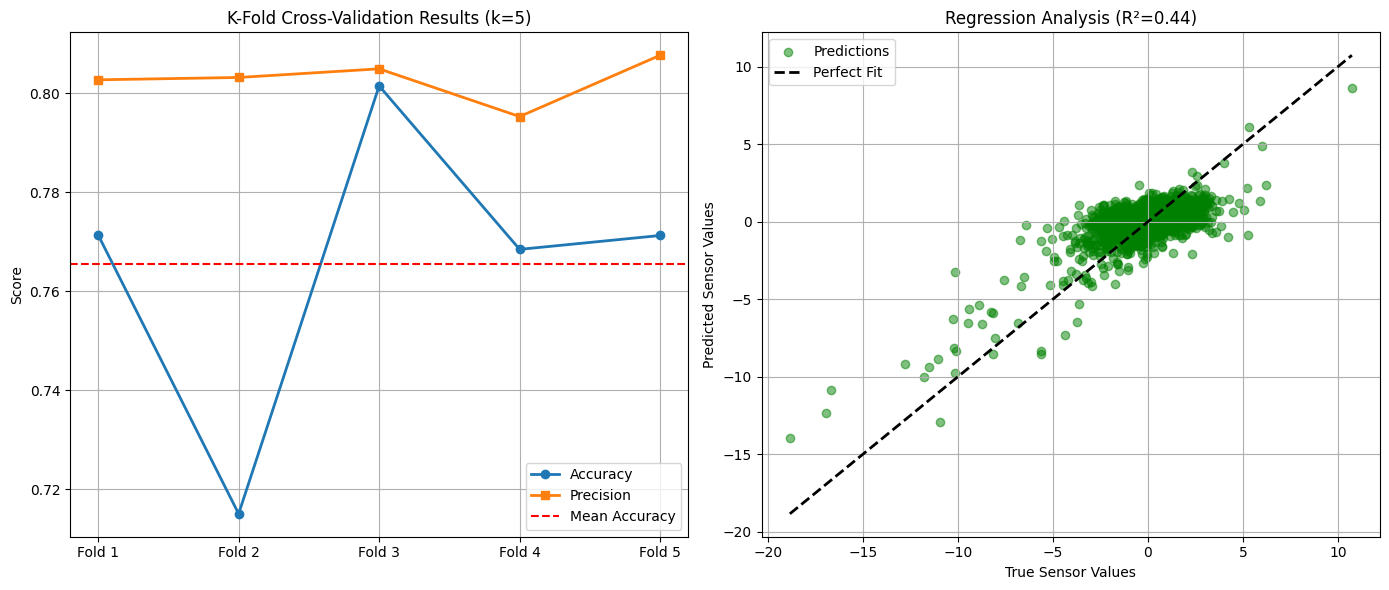

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

tf.random.set_seed(42)
np.random.seed(42)

filename = 'HAR_35colums_22L-7683 & 22L-6246.csv'
try:
    df = pd.read_csv(filename)
except FileNotFoundError:
    raise

X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
NUM_CLASSES = len(np.unique(y_encoded))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_categorical = keras.utils.to_categorical(y_encoded, NUM_CLASSES)

input_dim = X_scaled.shape[1]

print("\n--- PART A: K-Fold Cross-Validation (Classification) ---")

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracy = []
fold_precision = []
fold_recall = []

fold_no = 1

for train_index, val_index in kf.split(X_scaled):
    tf.keras.backend.clear_session()

    X_train_fold, X_val_fold = X_scaled[train_index], X_scaled[val_index]
    y_train_fold, y_val_fold = y_categorical[train_index], y_categorical[val_index]

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    print(f"Training Fold {fold_no} / {k} ...")
    model.fit(X_train_fold, y_train_fold, epochs=10, batch_size=32, verbose=0)

    y_pred_probs = model.predict(X_val_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_val_fold, axis=1)

    acc = accuracy_score(y_true_classes, y_pred_classes)
    prec = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
    rec = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)

    fold_accuracy.append(acc)
    fold_precision.append(prec)
    fold_recall.append(rec)

    fold_no += 1

print(f"Completed {k}-Fold CV successfully.")


print("\n--- PART B: Regression Metrics (MSE & R²) ---")

X_reg = X_scaled[:, 1:]
y_reg = X_scaled[:, 0]

reg_input_dim = X_reg.shape[1]

reg_model = keras.Sequential([
    layers.Input(shape=(reg_input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
reg_model.compile(loss='mse', optimizer='adam')

print("Training Regression Model...")
reg_model.fit(X_reg, y_reg, epochs=20, verbose=0)

y_reg_pred = reg_model.predict(X_reg, verbose=0)

mse_score = mean_squared_error(y_reg, y_reg_pred)
r2_score_val = r2_score(y_reg, y_reg_pred)


print("\n" + "="*40)
print("     FINAL EVALUATION RESULTS")
print("="*40)

metrics_df = pd.DataFrame({
    'Fold': range(1, k+1),
    'Accuracy': fold_accuracy,
    'Precision': fold_precision,
    'Recall': fold_recall
})
metrics_df.loc['Mean'] = metrics_df.mean()
print("\nClassification Metrics (K-Fold):")
print(metrics_df.round(4).to_markdown())

print("\nRegression Metrics (Feature Prediction):")
print(f"Mean Squared Error (MSE): {mse_score:.4f}")
print(f"R² Score:                 {r2_score_val:.4f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
x_labels = [f'Fold {i}' for i in range(1, k+1)]
plt.plot(x_labels, fold_accuracy, marker='o', label='Accuracy', linewidth=2)
plt.plot(x_labels, fold_precision, marker='s', label='Precision', linewidth=2)
plt.axhline(np.mean(fold_accuracy), color='r', linestyle='--', label='Mean Accuracy')
plt.title(f'K-Fold Cross-Validation Results (k={k})')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_reg, y_reg_pred, alpha=0.5, color='green', label='Predictions')
min_val = min(y_reg.min(), y_reg_pred.min())
max_val = max(y_reg.max(), y_reg_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Fit')
plt.title(f'Regression Analysis (R²={r2_score_val:.2f})')
plt.xlabel('True Sensor Values')
plt.ylabel('Predicted Sensor Values')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

 Part A: K-Means Analysis 
Part B: Hierarchical Clustering


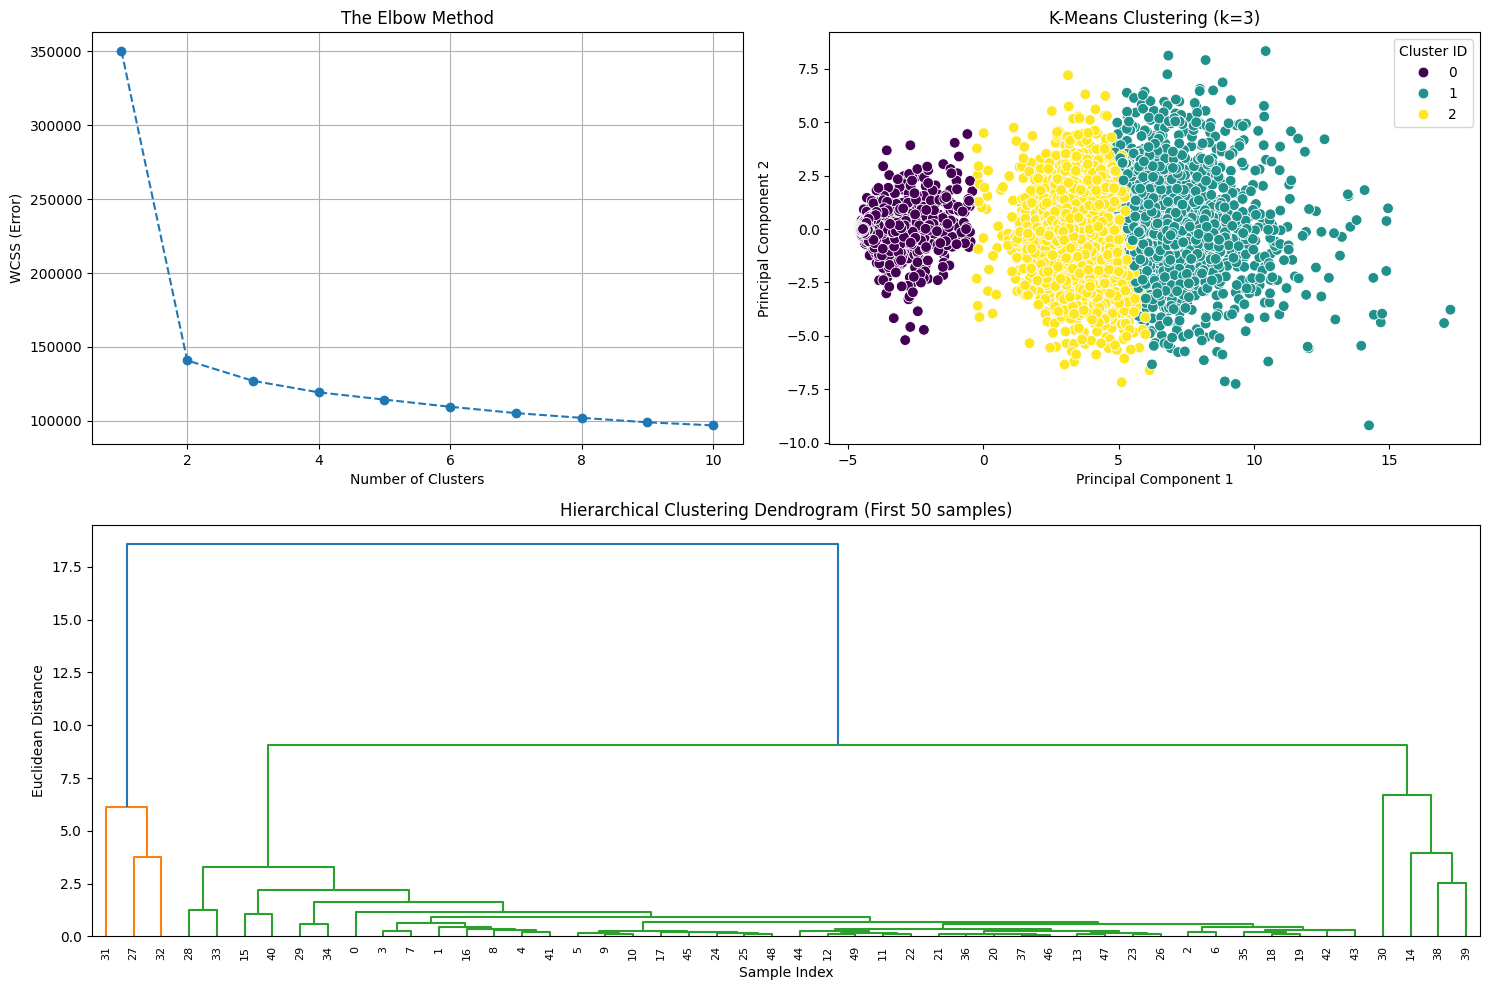


Analysis Complete. Data grouped into 3 clusters.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

np.random.seed(42)

df = pd.read_csv('HAR_35colums_22L-7683 & 22L-6246.csv')
X = df.iloc[:, :-1].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(" Part A: K-Means Analysis ")

wcss = []
range_n_clusters = range(1, 11)

for i in range_n_clusters:
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = y_kmeans


print("Part B: Hierarchical Clustering")
sample_size = 50
X_sample = X_scaled[:sample_size]


plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(range_n_clusters, wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Error)')
plt.grid(True)

plt.subplot(2, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=60)
plt.title(f'K-Means Clustering (k={optimal_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster ID')

plt.subplot(2, 1, 2)
plt.title(f'Hierarchical Clustering Dendrogram (First {sample_size} samples)')
dendrogram = sch.dendrogram(sch.linkage(X_sample, method='ward'))
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')

plt.tight_layout()
plt.show()

print(f"\nAnalysis Complete. Data grouped into {optimal_k} clusters.")

Data Shape: (10299, 35)
 Applying Dimensionality Reduction 
Performance Comparison (Logistic Regression) 
| Technique              |   Accuracy |
|:-----------------------|-----------:|
| Original (35 Features) |   0.842395 |
| PCA (2 Features)       |   0.452104 |
| LDA (2 Features)       |   0.580906 |


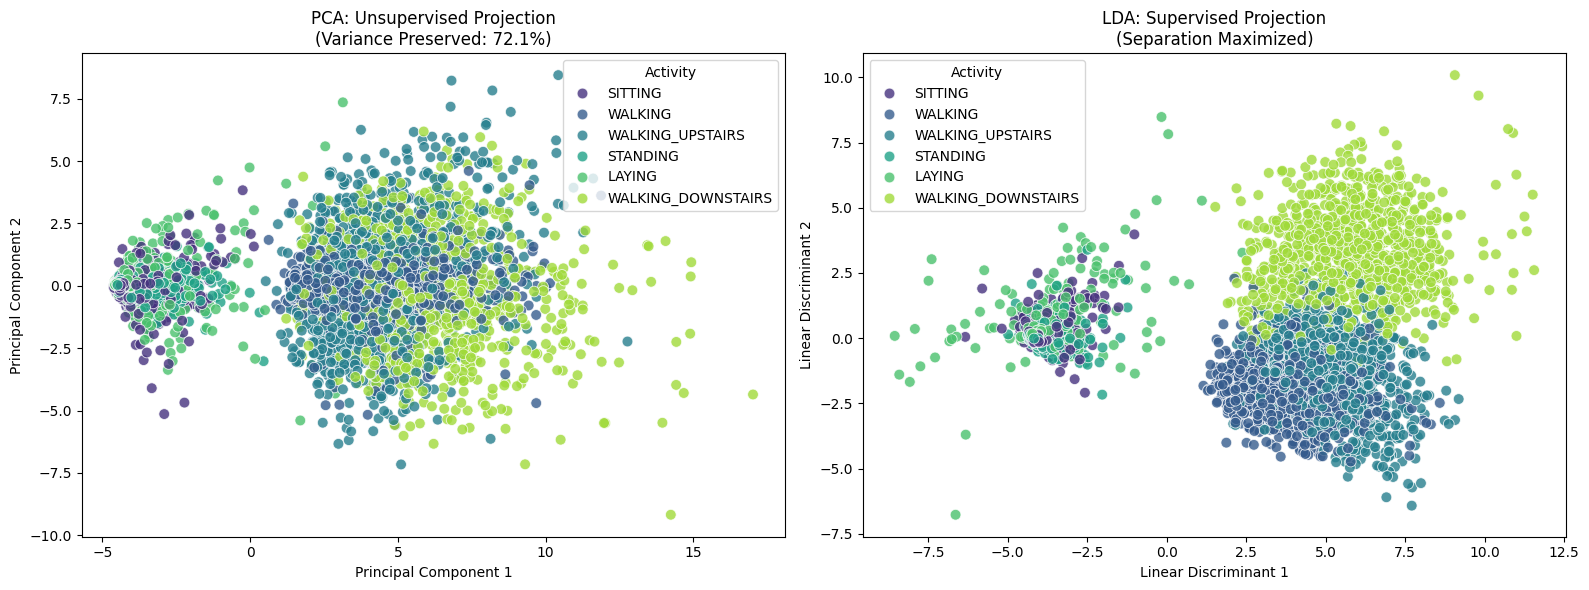

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)


df = pd.read_csv('HAR_35colums_22L-7683 & 22L-6246.csv')
print(f"Data Shape: {df.shape}")

X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(" Applying Dimensionality Reduction ")

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

n_lda_components = min(2, len(class_names) - 1)
lda = LDA(n_components=n_lda_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)


print("Performance Comparison (Logistic Regression) ")

def evaluate_model(X_tr, X_te, name):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    return accuracy_score(y_test, preds)

acc_full = evaluate_model(X_train_scaled, X_test_scaled, "Original (35D)")
acc_pca = evaluate_model(X_train_pca, X_test_pca, "PCA (2D)")
if n_lda_components >= 1:
    acc_lda = evaluate_model(X_train_lda, X_test_lda, f"LDA ({n_lda_components}D)")
else:
    acc_lda = 0

results = pd.DataFrame({
    'Technique': ['Original (35 Features)', 'PCA (2 Features)', f'LDA ({n_lda_components} Features)'],
    'Accuracy': [acc_full, acc_pca, acc_lda]
})
print(results.to_markdown(index=False))


plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=le.inverse_transform(y_train), palette='viridis', s=60, alpha=0.8)
plt.title(f'PCA: Unsupervised Projection\n(Variance Preserved: {np.sum(pca.explained_variance_ratio_):.1%})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Activity')

plt.subplot(1, 2, 2)
if n_lda_components == 2:
    sns.scatterplot(x=X_train_lda[:, 0], y=X_train_lda[:, 1], hue=le.inverse_transform(y_train), palette='viridis', s=60, alpha=0.8)
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Linear Discriminant 2')
elif n_lda_components == 1:
    sns.stripplot(x=X_train_lda[:, 0], y=le.inverse_transform(y_train), hue=le.inverse_transform(y_train), palette='viridis', jitter=True)
    plt.xlabel('Linear Discriminant 1')

plt.title(f'LDA: Supervised Projection\n(Separation Maximized)')
plt.legend(title='Activity')

plt.tight_layout()
plt.show()

1. Data Preparation

     ALGORITHM 1: BIRCH (Hierarchical Variant)
BIRCH Clustering Completed.
Silhouette Score: 0.4659

     ALGORITHM 2: RANDOM FOREST (Research Selection)
Random Forest Training Completed.
Test Accuracy: 0.8968


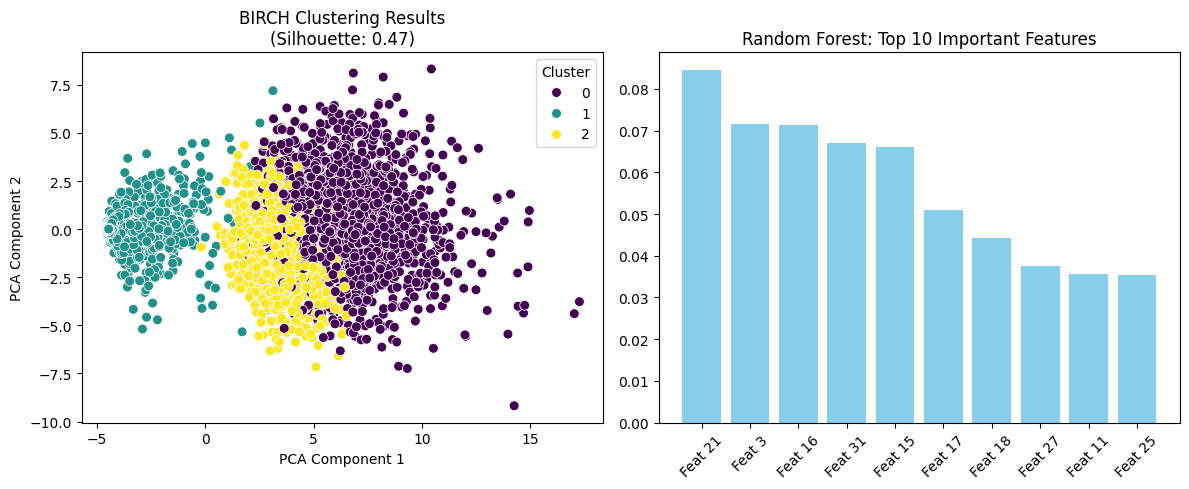


     COMPARATIVE PERFORMANCE ANALYSIS
| Task                        | Model                   | Metric           | Score         |
|:----------------------------|:------------------------|:-----------------|:--------------|
| Clustering (Unsupervised)   | K-Means (Task 10)       | Silhouette Score | Check Task 10 |
| Clustering (Unsupervised)   | BIRCH (Task 12)         | Silhouette Score | 0.4659        |
| Classification (Supervised) | MLP Neural Net (Task 9) | Accuracy         | Check Task 9  |
| Classification (Supervised) | Random Forest (Task 12) | Accuracy         | 0.8968        |


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.cluster import Birch
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

print("1. Data Preparation")

df = pd.read_csv('HAR_35colums_22L-7683 & 22L-6246.csv')

X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

le = LabelEncoder()
y = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


print("\n" + "="*50)
print("     ALGORITHM 1: BIRCH (Hierarchical Variant)")
print("="*50)

birch_model = Birch(n_clusters=3, threshold=0.5, branching_factor=50)
y_birch = birch_model.fit_predict(X_scaled)

birch_score = silhouette_score(X_scaled, y_birch)
print(f"BIRCH Clustering Completed.")
print(f"Silhouette Score: {birch_score:.4f}")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_birch, palette='viridis', s=50)
plt.title(f'BIRCH Clustering Results\n(Silhouette: {birch_score:.2f})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')


print("\n" + "="*50)
print("     ALGORITHM 2: RANDOM FOREST (Research Selection)")
print("="*50)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Training Completed.")
print(f"Test Accuracy: {rf_acc:.4f}")

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.subplot(1, 2, 2)
plt.title("Random Forest: Top 10 Important Features")
plt.bar(range(10), importances[indices[:10]], align="center", color='skyblue')
plt.xticks(range(10), [f'Feat {i}' for i in indices[:10]], rotation=45)
plt.tight_layout()
plt.show()


print("\n" + "="*50)
print("     COMPARATIVE PERFORMANCE ANALYSIS")
print("="*50)

comparison_data = [
    {"Task": "Clustering (Unsupervised)", "Model": "K-Means (Task 10)", "Metric": "Silhouette Score", "Score": "Check Task 10"},
    {"Task": "Clustering (Unsupervised)", "Model": "BIRCH (Task 12)", "Metric": "Silhouette Score", "Score": round(birch_score, 4)},
    {"Task": "Classification (Supervised)", "Model": "MLP Neural Net (Task 9)", "Metric": "Accuracy", "Score": "Check Task 9"},
    {"Task": "Classification (Supervised)", "Model": "Random Forest (Task 12)", "Metric": "Accuracy", "Score": round(rf_acc, 4)},
]

df_results = pd.DataFrame(comparison_data)
print(df_results.to_markdown(index=False))

1. Loading & Preparing Data 
Data is large (10299 rows). Sampling 1500 random rows for speed...

2. Running t-SNE (Optimized) 
t-SNE Complete.


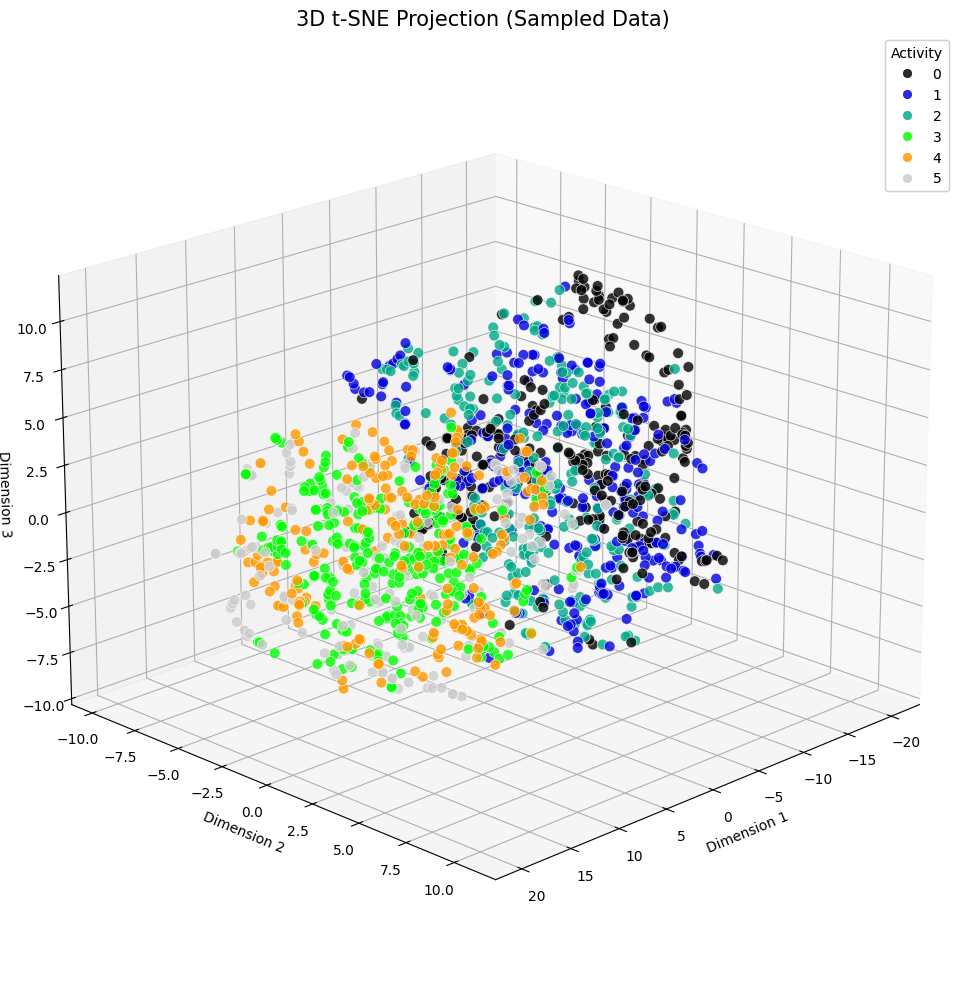

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder

np.random.seed(42)

print("1. Loading & Preparing Data ")
df = pd.read_csv('HAR_35colums_22L-7683 & 22L-6246.csv')

X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

# --- OPTIMIZATION STEP: SAMPLING ---
limit = 1500
if len(X) > limit:
    print(f"Data is large ({len(X)} rows). Sampling {limit} random rows for speed...")
    indices = np.random.choice(len(X), limit, replace=False)
    X = X[indices]
    y_raw = y_raw[indices]
else:
    print(f"Data size is manageable ({len(X)} rows). Using all data.")

le = LabelEncoder()
y = le.fit_transform(y_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n2. Running t-SNE (Optimized) ")
tsne = TSNE(n_components=3, perplexity=30, max_iter=500, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE Complete.")


# --- 3. The Awesome 3D Visualization ---

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    X_tsne[:, 2],
    c=y,
    cmap='nipy_spectral',
    s=60,
    alpha=0.8,
    edgecolors='w',
    linewidth=0.5
)

ax.set_title('3D t-SNE Projection (Sampled Data)', fontsize=15)
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')

legend1 = ax.legend(*scatter.legend_elements(), title="Activity", loc="upper right")
ax.add_artist(legend1)

ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

In [53]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder

np.random.seed(42)

print("1. Preparing Data")

df = pd.read_csv('HAR_35colums_22L-7683 & 22L-6246.csv')

X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

# --- SPEED OPTIMIZATION (Sampling) ---
limit = 2000
if len(X) > limit:
    print(f"Sampling {limit} random points for speed...")
    indices = np.random.choice(len(X), limit, replace=False)
    X = X[indices]
    y_raw = y_raw[indices]

y = y_raw

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("--- 2. Running t-SNE (Calculating 3D Layout) ---")
tsne = TSNE(n_components=3, perplexity=30, max_iter=500, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

plot_df = pd.DataFrame(data=X_tsne, columns=['x', 'y', 'z'])
plot_df['Activity'] = y

print("--- 3. Generating Interactive Plot ---")

fig = px.scatter_3d(
    plot_df,
    x='x',
    y='y',
    z='z',
    color='Activity',
    title="Interactive 3D t-SNE: Human Activity Recognition",
    opacity=0.7,
    size_max=5
)

fig.update_traces(marker=dict(size=3))

fig.show()

fig.write_html("interactive_activity_plot.html")
print("Saved interactive chart to 'interactive_activity_plot.html'")

1. Preparing Data
Sampling 2000 random points for speed...
--- 2. Running t-SNE (Calculating 3D Layout) ---
--- 3. Generating Interactive Plot ---


Saved interactive chart to 'interactive_activity_plot.html'
